In [ ]:
import subprocess, sys
def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=False)

try:
    import open_mythos  # noqa: F401
except Exception:
    pip("open-mythos")
    try:
        import open_mythos  # noqa: F401
    except Exception:
        pip("git+https://github.com/kyegomez/OpenMythos.git")

import math, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from open_mythos.main import OpenMythos, MythosConfig

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device} | Torch: {torch.__version__}")

In [ ]:
def build_model(attn_type: str = "mla", max_loop_iters: int = 8) -> tuple:
    """Build a small OpenMythos model. Two attention variants supported.

    MLA  — Multi-Latent Attention (compressed KV cache, DeepSeek-V2 style)
    GQA  — Grouped-Query Attention (fewer KV heads than Q heads)
    """
    base = dict(
        vocab_size       = 64,
        dim              = 128,
        n_heads          = 4,
        max_seq_len      = 32,
        max_loop_iters   = max_loop_iters,
        prelude_layers   = 1,
        coda_layers      = 1,
        n_experts        = 4,
        n_shared_experts = 1,
        n_experts_per_tok= 2,
        expert_dim       = 64,
        lora_rank        = 8,
        attn_type        = attn_type,
    )
    if attn_type == "gqa":
        cfg = MythosConfig(**base, n_kv_heads=2)
    else:
        cfg = MythosConfig(
            **base, n_kv_heads=4,
            kv_lora_rank=32, q_lora_rank=32,
            qk_rope_head_dim=16, qk_nope_head_dim=16, v_head_dim=16,
        )
    model = OpenMythos(cfg).to(device)
    return model, cfg

model_mla, cfg_mla = build_model("mla")
model_gqa, cfg_gqa = build_model("gqa")

def n_params(m): return sum(p.numel() for p in m.parameters())
print(f"\n[MLA] params: {n_params(model_mla):>10,}")
print(f"[GQA] params: {n_params(model_gqa):>10,}")

def spectral_radius(model):
    A = model.recurrent.injection.get_A().detach().cpu()
    if A.dim() == 1:
        rho = A.abs().max().item()
    else:
        rho = torch.linalg.eigvals(A.float()).abs().max().item()
    return rho

print(f"\nρ(A) MLA: {spectral_radius(model_mla):.4f}   (must be < 1)")
print(f"ρ(A) GQA: {spectral_radius(model_gqa):.4f}   (must be < 1)")

ids = torch.randint(0, cfg_mla.vocab_size, (2, 16), device=device)
with torch.no_grad():
    logits = model_mla(ids, n_loops=4)
    gen    = model_mla.generate(ids, max_new_tokens=4, n_loops=8)
print(f"\nForward logits shape:  {tuple(logits.shape)}")
print(f"Generation shape:      {tuple(gen.shape)}")

In [ ]:
PAD, START, EQ = 0, 1, 2
DIGIT_BASE     = 10
M              = 7
SEQ_LEN        = cfg_mla.max_seq_len
MIN_LEN, MAX_LEN = 2, 5

def make_example(chain_len: int):
    digits = [random.randint(0, M-1) for _ in range(chain_len)]
    target = sum(digits) % M
    toks = [START] + [DIGIT_BASE + d for d in digits] + [EQ]
    toks = toks + [PAD] * (SEQ_LEN - len(toks))
    return toks[:SEQ_LEN], DIGIT_BASE + target

class ChainDataset(Dataset):
    def __init__(self, n, lo, hi):
        self.items = [make_example(random.randint(lo, hi)) for _ in range(n)]
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        x, y = self.items[i]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

train_loader = DataLoader(ChainDataset(3000, MIN_LEN, MAX_LEN), batch_size=64, shuffle=True)
test_loader  = DataLoader(ChainDataset(400,  MIN_LEN, MAX_LEN), batch_size=64)
ood_loader   = DataLoader(ChainDataset(400,  MAX_LEN+1, MAX_LEN+3), batch_size=64)

In [ ]:
model   = model_mla
TRAIN_LOOPS = 4
EPOCHS  = 6

opt   = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.01)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)

def loss_at_eq(logits, x, y):
    """Predict the answer at the position immediately after the EQ token."""
    eq_pos = (x == EQ).int().argmax(dim=1)
    pred   = logits[torch.arange(x.size(0)), eq_pos]
    return F.cross_entropy(pred, y), pred

train_losses = []
print("\n--- Training ---")
t0 = time.time()
for ep in range(EPOCHS):
    model.train(); running = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x, n_loops=TRAIN_LOOPS)
        loss, _ = loss_at_eq(logits, x, y)
        opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        running += loss.item()
    sched.step()
    train_losses.append(running / len(train_loader))
    print(f"  epoch {ep+1}/{EPOCHS}  loss={train_losses[-1]:.4f}  ρ(A)={spectral_radius(model):.3f}")
print(f"Train time: {time.time()-t0:.1f}s")

@torch.no_grad()
def accuracy(loader, n_loops):
    model.eval(); correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x, n_loops=n_loops)
        _, pred = loss_at_eq(logits, x, y)
        correct += (pred.argmax(-1) == y).sum().item()
        total   += y.size(0)
    return correct / total

LOOP_GRID = [1, 2, 4, 6, 8]
print("\n--- Loop-count scaling (same weights, varying compute) ---")
in_dist_acc  = [accuracy(test_loader, L) for L in LOOP_GRID]
ood_acc      = [accuracy(ood_loader,  L) for L in LOOP_GRID]
for L, a, o in zip(LOOP_GRID, in_dist_acc, ood_acc):
    print(f"  n_loops={L}: in-dist acc={a:.3f}   OOD (longer chains) acc={o:.3f}")

Device: cpu | Torch: 2.11.0+cu130

[MLA] params:    370,306
[GQA] params:    437,698

ρ(A) MLA: 0.3679   (must be < 1)
ρ(A) GQA: 0.3679   (must be < 1)

Forward logits shape:  (2, 16, 64)
Generation shape:      (2, 20)

--- Training ---
  epoch 1/6  loss=2.8642  ρ(A)=0.372
  epoch 2/6  loss=2.0255  ρ(A)=0.373
  epoch 3/6  loss=1.9791  ρ(A)=0.373
  epoch 4/6  loss=1.9654  ρ(A)=0.373
  epoch 5/6  loss=1.9619  ρ(A)=0.373
  epoch 6/6  loss=1.9586  ρ(A)=0.373
Train time: 103.9s

--- Loop-count scaling (same weights, varying compute) ---
  n_loops=1: in-dist acc=0.142   OOD (longer chains) acc=0.152
  n_loops=2: in-dist acc=0.142   OOD (longer chains) acc=0.152
  n_loops=4: in-dist acc=0.142   OOD (longer chains) acc=0.152
  n_loops=6: in-dist acc=0.142   OOD (longer chains) acc=0.152
  n_loops=8: in-dist acc=0.142   OOD (longer chains) acc=0.152


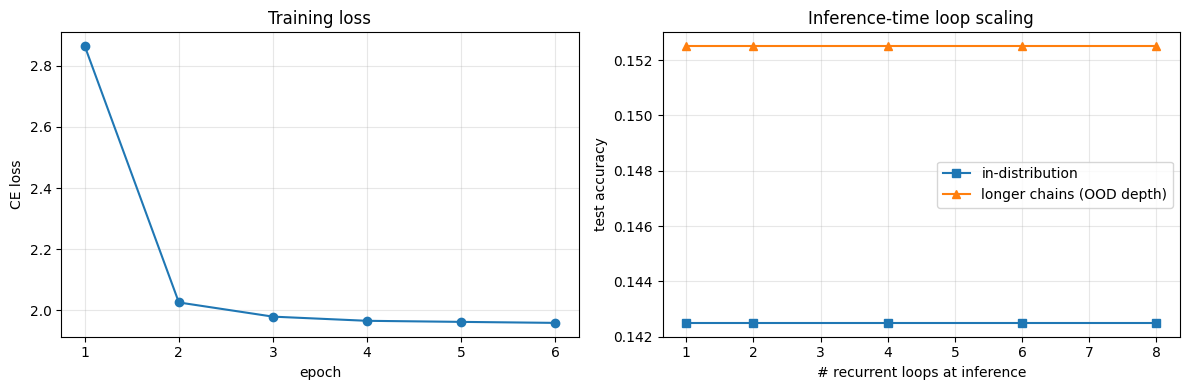


Demo: digits=[3, 6, 0, 2], target=(3+6+0+2) % 7 = 4
      true token=14 (digit 4)  |  predicted token=15 (digit 5)

Done. Key takeaway: at inference, increasing n_loops trades compute for
reasoning depth on the same fixed-parameter model — that's the RDT premise.


In [1]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS+1), train_losses, marker="o")
axes[0].set_title("Training loss"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("CE loss")
axes[0].grid(alpha=0.3)

axes[1].plot(LOOP_GRID, in_dist_acc, marker="s", label="in-distribution")
axes[1].plot(LOOP_GRID, ood_acc,     marker="^", label="longer chains (OOD depth)")
axes[1].set_title("Inference-time loop scaling")
axes[1].set_xlabel("# recurrent loops at inference"); axes[1].set_ylabel("test accuracy")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

chain_len = 4
toks, true_tok = make_example(chain_len)
digits = [t - DIGIT_BASE for t in toks if t >= DIGIT_BASE]
prompt = torch.tensor([toks], device=device)
with torch.no_grad():
    gen = model.generate(prompt, max_new_tokens=1, n_loops=8)
predicted = gen[0, -1].item()
print(f"\nDemo: digits={digits}, target=({'+'.join(map(str, digits))}) % {M} = {sum(digits)%M}")
print(f"      true token={true_tok} (digit {true_tok-DIGIT_BASE})  |  "
      f"predicted token={predicted} (digit {predicted-DIGIT_BASE if predicted>=DIGIT_BASE else '?'})")

print("\nDone. Key takeaway: at inference, increasing n_loops trades compute for")
print("reasoning depth on the same fixed-parameter model — that's the RDT premise.")